# Exploratory Data Analysis: Market Regime Detection for RL Allocation

This notebook performs comprehensive EDA on the market features dataset used for training a market regime detection system for RL-based portfolio allocation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats
from pathlib import Path

warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

## Section 1: Load and Inspect Data

This section loads the market features dataset and examines its structure, shape, data types, and first few rows.

In [2]:
# Load market features data
data_path = Path('data/processed/market_features_weekly.csv')
df_market = pd.read_csv(data_path)

print("Dataset Shape:", df_market.shape)
print("\nFirst few rows:")
print(df_market.head())
print("\nColumn Names and Data Types:")
print(df_market.dtypes)
print("\nBasic Info:")
print(df_market.info())

Dataset Shape: (638, 38)

First few rows:
     week_end  spy_ret_1d  spy_ret_5d  spy_ret_20d  spy_vol_5d  spy_vol_20d  \
0  2014-01-03   -0.000164         NaN          NaN         NaN          NaN   
1  2014-01-10    0.002719    0.006811          NaN    0.003336          NaN   
2  2014-01-17   -0.004239   -0.002719          NaN    0.009273          NaN   
3  2014-01-24   -0.021567   -0.030445          NaN    0.009675          NaN   
4  2014-01-31   -0.005876   -0.003976    -0.026255    0.008592     0.007964   

   spy_drawdown_60d  spy_ma_gap_5_20  spy_intraday_range  spy_volume_z_20  \
0               NaN              NaN            0.005304              NaN   
1               NaN              NaN            0.006571              NaN   
2               NaN              NaN            0.006153              NaN   
3               NaN              NaN            0.015820              NaN   
4               NaN        -0.019986            0.013301         1.536965   

   ...  qqq_spy_log_

## Section 2: Data Quality Assessment

This section checks for missing values, duplicates, and data quality issues.

In [3]:
# Check for missing values
print("Missing Values Count:")
missing_count = df_market.isnull().sum()
print(missing_count[missing_count > 0])
print("\nMissing Values Percentage:")
missing_pct = (df_market.isnull().sum() / len(df_market) * 100)
print(missing_pct[missing_pct > 0])

# Check for duplicates
print(f"\nNumber of duplicate rows: {df_market.duplicated().sum()}")

# Summary statistics
print("\nBasic Statistical Summary:")
print(df_market.describe())

Missing Values Count:
spy_ret_5d               1
spy_ret_20d              4
spy_vol_5d               1
spy_vol_20d              4
spy_drawdown_60d        12
spy_ma_gap_5_20          4
spy_volume_z_20          4
tlt_ret_5d               1
tlt_ret_20d              4
tlt_vol_5d               1
tlt_vol_20d              4
tlt_drawdown_60d        12
tlt_ma_gap_5_20          4
tlt_volume_z_20          4
gld_ret_5d               1
gld_ret_20d              4
gld_vol_5d               1
gld_vol_20d              4
gld_drawdown_60d        12
gld_ma_gap_5_20          4
gld_volume_z_20          4
qqq_spy_ratio_chg_5d     1
spy_tlt_corr_20d         4
spy_gld_corr_20d         4
vix_change_5d            1
tnx_change_5d            1
dtype: int64

Missing Values Percentage:
spy_ret_5d              0.156740
spy_ret_20d             0.626959
spy_vol_5d              0.156740
spy_vol_20d             0.626959
spy_drawdown_60d        1.880878
spy_ma_gap_5_20         0.626959
spy_volume_z_20         0.626959
tlt_

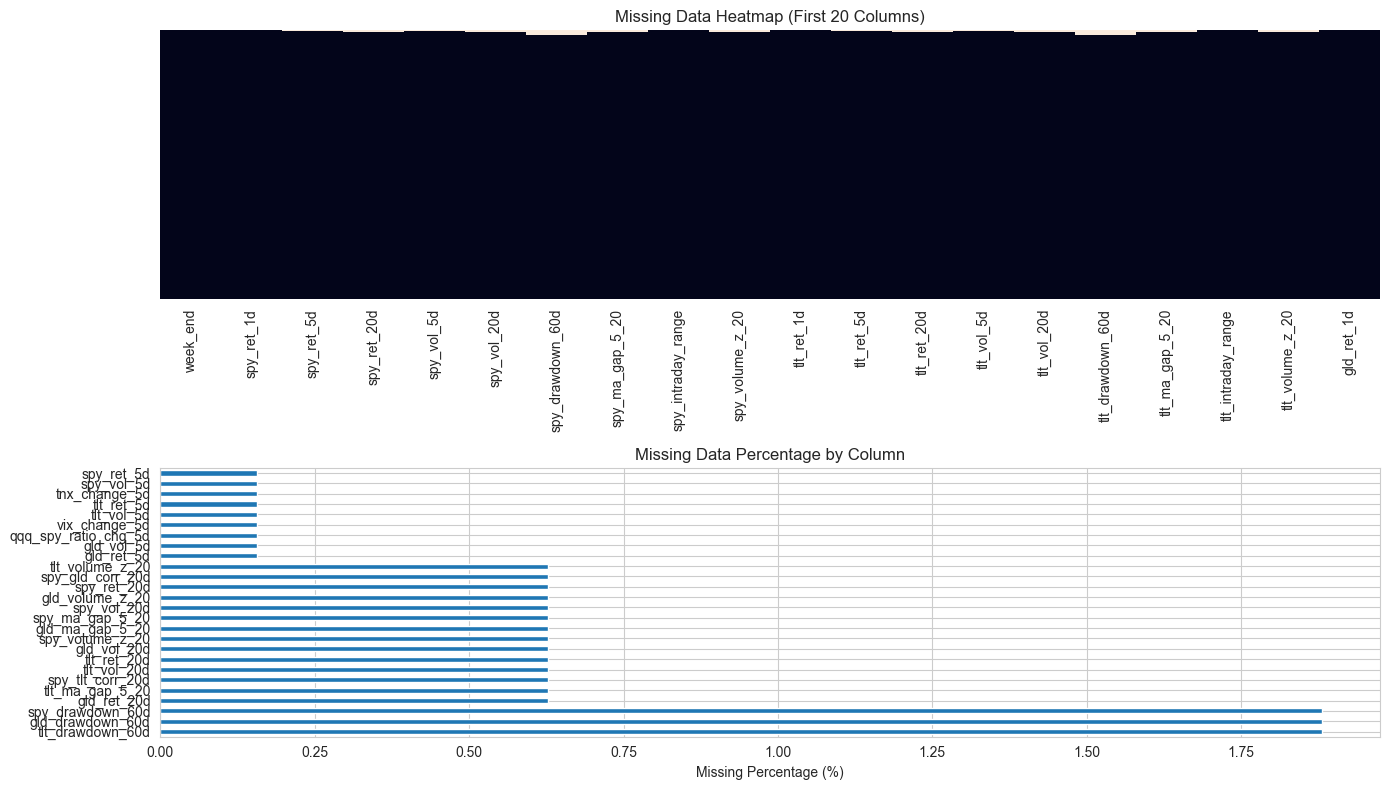

In [4]:
# Visualize missing data patterns
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Missing data heatmap
missing_data = df_market.isnull()
sns.heatmap(missing_data.iloc[:, :20], cbar=False, yticklabels=False, ax=axes[0])
axes[0].set_title('Missing Data Heatmap (First 20 Columns)')

# Bar plot of missing percentages
missing_pct_all = (df_market.isnull().sum() / len(df_market) * 100).sort_values(ascending=False)
missing_pct_all[missing_pct_all > 0].plot(kind='barh', ax=axes[1])
axes[1].set_xlabel('Missing Percentage (%)')
axes[1].set_title('Missing Data Percentage by Column')

plt.tight_layout()
plt.show()

## Section 3: Univariate Analysis

This section analyzes individual features using distributions and summary statistics.

In [5]:
# Select key numeric columns for analysis (exclude date/index columns)
numeric_cols = df_market.select_dtypes(include=[np.number]).columns.tolist()
print(f"Number of numeric columns: {len(numeric_cols)}")
print(f"Numeric columns: {numeric_cols[:10]}...")  # Show first 10

# Analyze key market indices returns
key_returns = ['spy_ret_1d', 'spy_ret_5d', 'spy_ret_20d', 
               'tlt_ret_1d', 'tlt_ret_5d', 'tlt_ret_20d',
               'gld_ret_1d', 'gld_ret_5d', 'gld_ret_20d']

print("\n=== Returns Statistics ===")
print(df_market[key_returns].describe())

Number of numeric columns: 35
Numeric columns: ['spy_ret_1d', 'spy_ret_5d', 'spy_ret_20d', 'spy_vol_5d', 'spy_vol_20d', 'spy_drawdown_60d', 'spy_ma_gap_5_20', 'spy_intraday_range', 'spy_volume_z_20', 'tlt_ret_1d']...

=== Returns Statistics ===
       spy_ret_1d  spy_ret_5d  spy_ret_20d  tlt_ret_1d  tlt_ret_5d  \
count  638.000000  637.000000   634.000000  638.000000  637.000000   
mean     0.000454    0.002471     0.009841    0.000510    0.000265   
std      0.010732    0.022666     0.043561    0.009489    0.019470   
min     -0.060327   -0.157189    -0.370872   -0.026359   -0.080053   
25%     -0.003633   -0.008081    -0.007822   -0.005623   -0.010260   
50%      0.000774    0.004042     0.015594    0.000757    0.000852   
75%      0.005760    0.014755     0.035279    0.006015    0.012798   
max      0.082028    0.102200     0.181328    0.072502    0.072668   

       tlt_ret_20d  gld_ret_1d  gld_ret_5d  gld_ret_20d  
count   634.000000  638.000000  637.000000   634.000000  
mean    

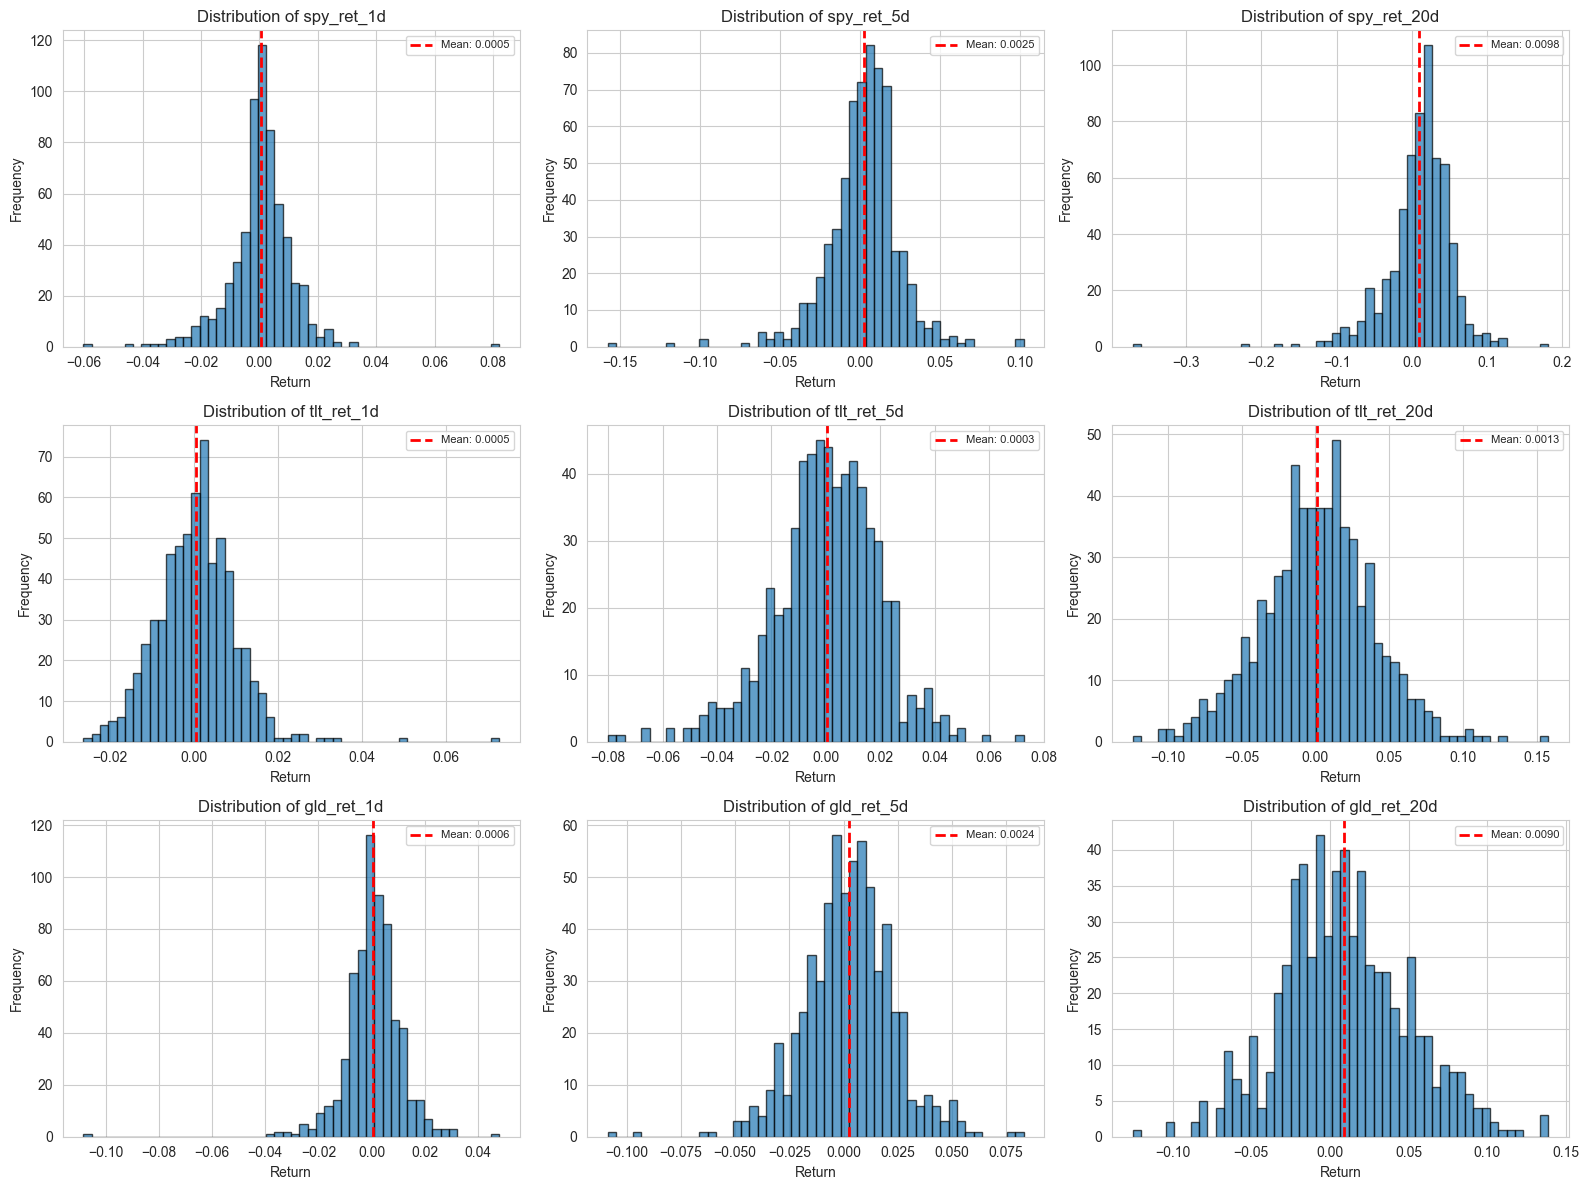

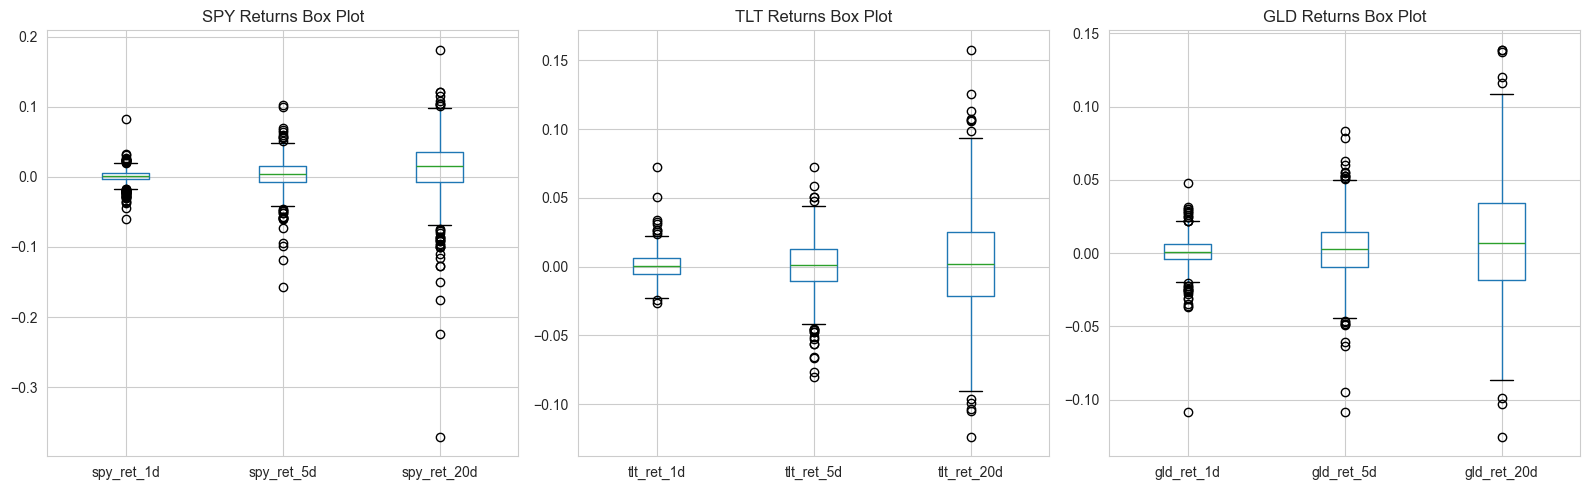

In [6]:
# Plot distributions of key returns
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for idx, col in enumerate(key_returns):
    data_clean = df_market[col].dropna()
    axes[idx].hist(data_clean, bins=50, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribution of {col}')
    axes[idx].set_xlabel('Return')
    axes[idx].set_ylabel('Frequency')
    
    # Add stats
    mean_val = data_clean.mean()
    std_val = data_clean.std()
    axes[idx].axvline(mean_val, color='r', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.4f}')
    axes[idx].legend(fontsize=8)

plt.tight_layout()
plt.show()

# Box plots for returns
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
df_market[['spy_ret_1d', 'spy_ret_5d', 'spy_ret_20d']].boxplot(ax=axes[0])
axes[0].set_title('SPY Returns Box Plot')
df_market[['tlt_ret_1d', 'tlt_ret_5d', 'tlt_ret_20d']].boxplot(ax=axes[1])
axes[1].set_title('TLT Returns Box Plot')
df_market[['gld_ret_1d', 'gld_ret_5d', 'gld_ret_20d']].boxplot(ax=axes[2])
axes[2].set_title('GLD Returns Box Plot')
plt.tight_layout()
plt.show()

## Section 4: Correlation Analysis

This section examines correlations between features.

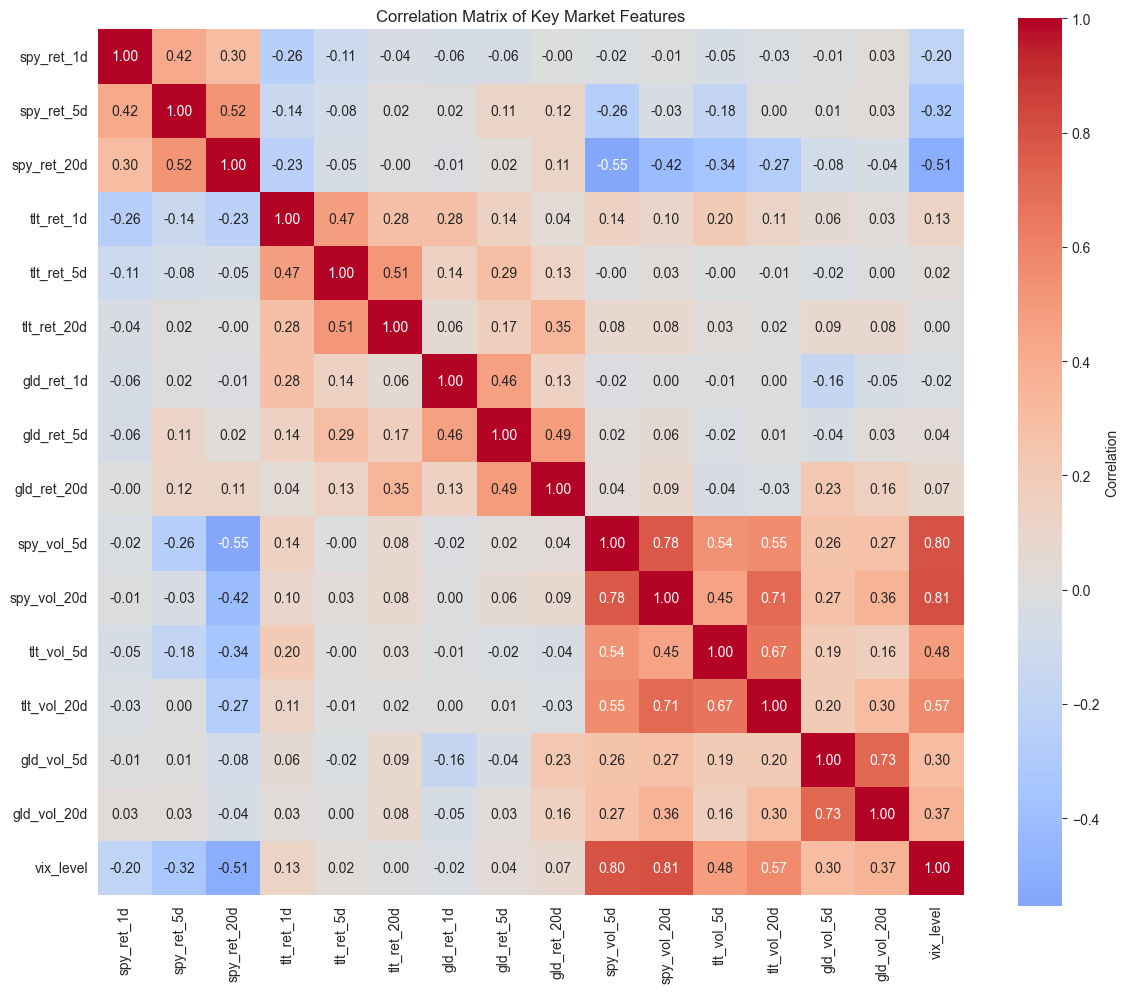

Correlation Matrix:
             spy_ret_1d  spy_ret_5d  spy_ret_20d  tlt_ret_1d  tlt_ret_5d  \
spy_ret_1d     1.000000    0.418017     0.297313   -0.255920   -0.111420   
spy_ret_5d     0.418017    1.000000     0.524895   -0.136971   -0.077128   
spy_ret_20d    0.297313    0.524895     1.000000   -0.231768   -0.052660   
tlt_ret_1d    -0.255920   -0.136971    -0.231768    1.000000    0.469651   
tlt_ret_5d    -0.111420   -0.077128    -0.052660    0.469651    1.000000   
tlt_ret_20d   -0.037583    0.016234    -0.002670    0.282050    0.511220   
gld_ret_1d    -0.058186    0.016266    -0.013789    0.283031    0.137726   
gld_ret_5d    -0.061224    0.113622     0.020648    0.142307    0.290723   
gld_ret_20d   -0.002411    0.118741     0.108322    0.042565    0.130788   
spy_vol_5d    -0.020569   -0.259073    -0.553962    0.135485   -0.003095   
spy_vol_20d   -0.012391   -0.034450    -0.416998    0.098907    0.026961   
tlt_vol_5d    -0.045997   -0.175035    -0.343465    0.199567   -0.00

In [7]:
# Compute correlation matrix for key features
key_features = ['spy_ret_1d', 'spy_ret_5d', 'spy_ret_20d', 
                'tlt_ret_1d', 'tlt_ret_5d', 'tlt_ret_20d',
                'gld_ret_1d', 'gld_ret_5d', 'gld_ret_20d',
                'spy_vol_5d', 'spy_vol_20d', 'tlt_vol_5d', 'tlt_vol_20d',
                'gld_vol_5d', 'gld_vol_20d', 'vix_level']

corr_matrix = df_market[key_features].corr()

# Plot correlation heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            cbar_kws={'label': 'Correlation'}, ax=ax, square=True)
ax.set_title('Correlation Matrix of Key Market Features')
plt.tight_layout()
plt.show()

print("Correlation Matrix:")
print(corr_matrix)

In [8]:
# Find highly correlated pairs
print("Highly Correlated Feature Pairs (|r| > 0.8):")
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            print(f"{corr_matrix.columns[i]} <-> {corr_matrix.columns[j]}: {corr_matrix.iloc[i, j]:.3f}")

Highly Correlated Feature Pairs (|r| > 0.8):
spy_vol_20d <-> vix_level: 0.809


## Section 5: Time Series Visualization

This section visualizes trends in market indices over time.

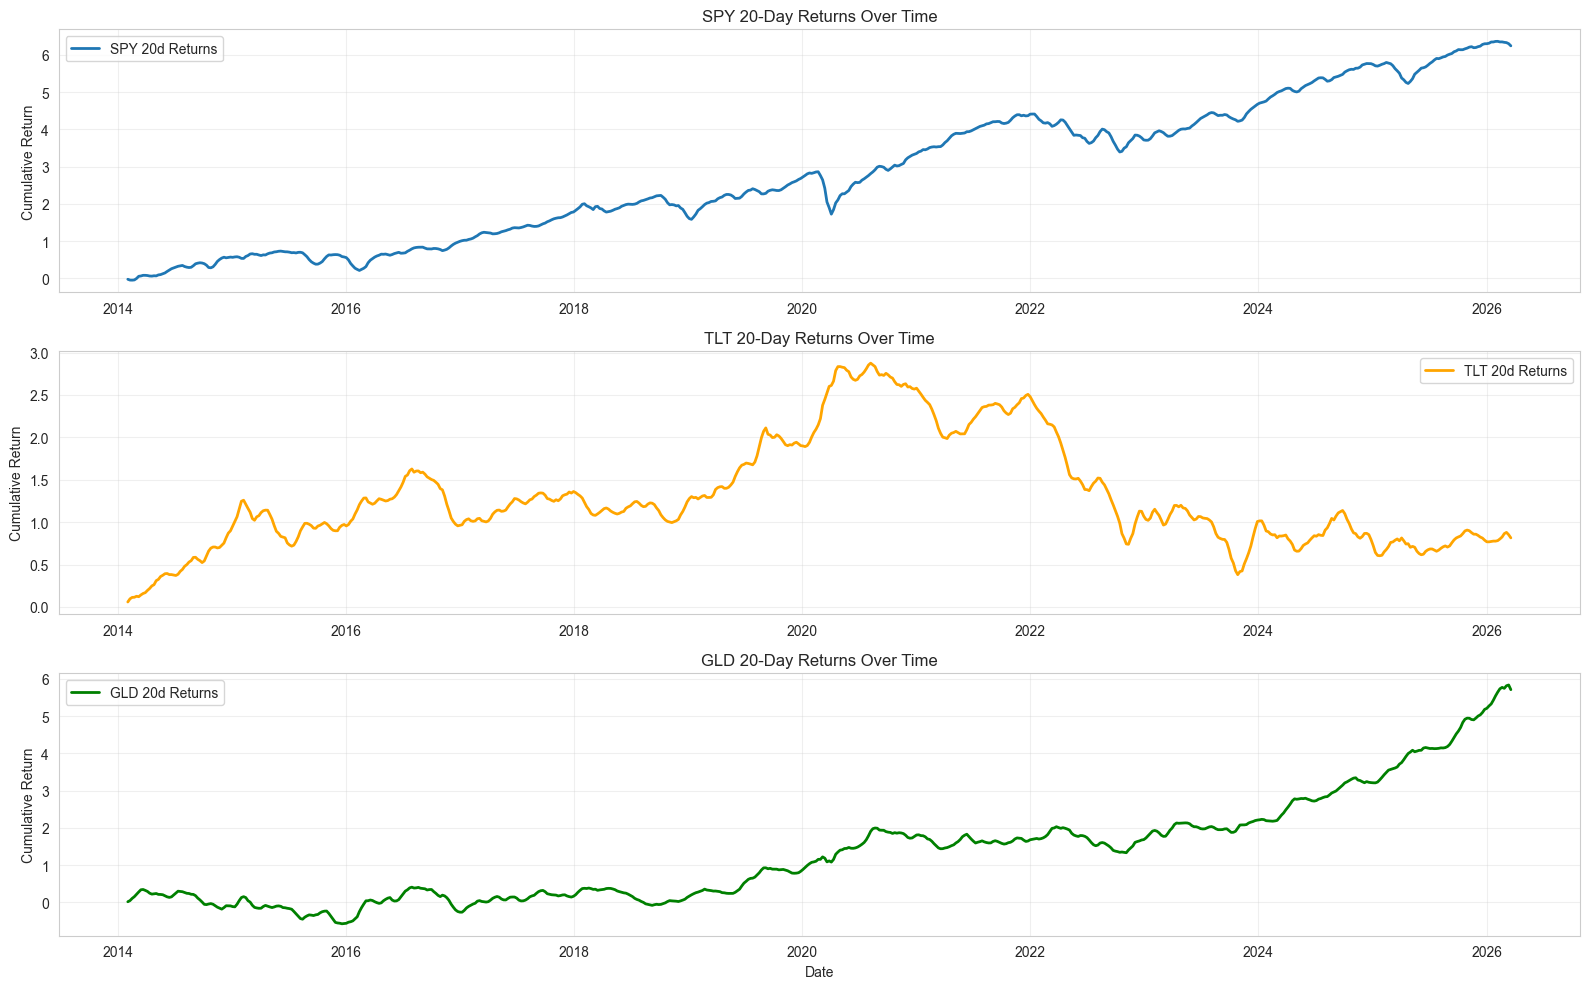

In [9]:
# Convert week_end to datetime
df_market['week_end_date'] = pd.to_datetime(df_market['week_end'])

# Plot time series of cumulative returns
fig, axes = plt.subplots(3, 1, figsize=(16, 10))

# SPY returns over time
spy_ret_20 = df_market[['week_end_date', 'spy_ret_20d']].dropna()
spy_ret_20['cumsum'] = spy_ret_20['spy_ret_20d'].cumsum()
axes[0].plot(spy_ret_20['week_end_date'], spy_ret_20['cumsum'], label='SPY 20d Returns', linewidth=2)
axes[0].set_title('SPY 20-Day Returns Over Time')
axes[0].set_ylabel('Cumulative Return')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# TLT returns over time
tlt_ret_20 = df_market[['week_end_date', 'tlt_ret_20d']].dropna()
tlt_ret_20['cumsum'] = tlt_ret_20['tlt_ret_20d'].cumsum()
axes[1].plot(tlt_ret_20['week_end_date'], tlt_ret_20['cumsum'], label='TLT 20d Returns', color='orange', linewidth=2)
axes[1].set_title('TLT 20-Day Returns Over Time')
axes[1].set_ylabel('Cumulative Return')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# GLD returns over time
gld_ret_20 = df_market[['week_end_date', 'gld_ret_20d']].dropna()
gld_ret_20['cumsum'] = gld_ret_20['gld_ret_20d'].cumsum()
axes[2].plot(gld_ret_20['week_end_date'], gld_ret_20['cumsum'], label='GLD 20d Returns', color='green', linewidth=2)
axes[2].set_title('GLD 20-Day Returns Over Time')
axes[2].set_ylabel('Cumulative Return')
axes[2].set_xlabel('Date')
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

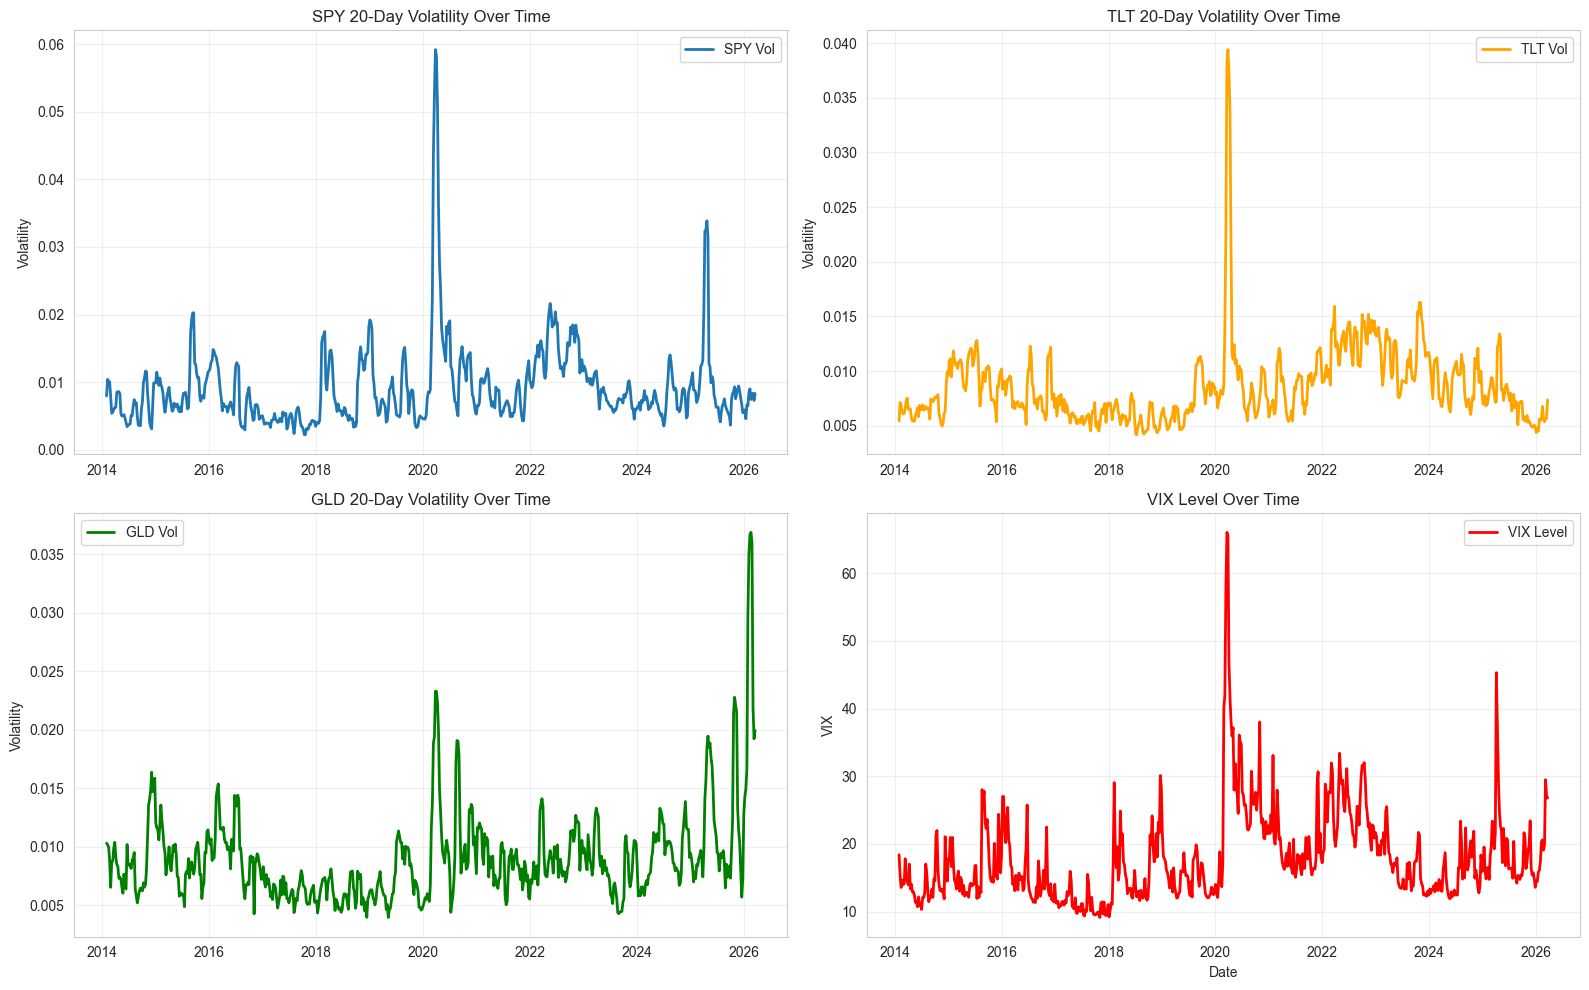

In [10]:
# Plot volatility trends
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Volatility time series
vol_data = df_market[['week_end_date', 'spy_vol_20d', 'tlt_vol_20d', 'gld_vol_20d', 'vix_level']].dropna()

axes[0, 0].plot(vol_data['week_end_date'], vol_data['spy_vol_20d'], label='SPY Vol', linewidth=2)
axes[0, 0].set_title('SPY 20-Day Volatility Over Time')
axes[0, 0].set_ylabel('Volatility')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

axes[0, 1].plot(vol_data['week_end_date'], vol_data['tlt_vol_20d'], label='TLT Vol', color='orange', linewidth=2)
axes[0, 1].set_title('TLT 20-Day Volatility Over Time')
axes[0, 1].set_ylabel('Volatility')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

axes[1, 0].plot(vol_data['week_end_date'], vol_data['gld_vol_20d'], label='GLD Vol', color='green', linewidth=2)
axes[1, 0].set_title('GLD 20-Day Volatility Over Time')
axes[1, 0].set_ylabel('Volatility')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

axes[1, 1].plot(vol_data['week_end_date'], vol_data['vix_level'], label='VIX Level', color='red', linewidth=2)
axes[1, 1].set_title('VIX Level Over Time')
axes[1, 1].set_ylabel('VIX')
axes[1, 1].set_xlabel('Date')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## Section 6: Statistical Summary

This section provides detailed statistical analysis including skewness, kurtosis, and distribution properties.

In [11]:
# Advanced statistical analysis for key returns
print("=" * 80)
print("ADVANCED STATISTICAL ANALYSIS FOR KEY RETURNS")
print("=" * 80)

for col in key_returns:
    data_clean = df_market[col].dropna()
    
    print(f"\n{col}:")
    print(f"  Mean: {data_clean.mean():.6f}")
    print(f"  Median: {data_clean.median():.6f}")
    print(f"  Std Dev: {data_clean.std():.6f}")
    print(f"  Skewness: {stats.skew(data_clean):.6f}")
    print(f"  Kurtosis: {stats.kurtosis(data_clean):.6f}")
    print(f"  Min: {data_clean.min():.6f}")
    print(f"  Max: {data_clean.max():.6f}")
    print(f"  Range: {data_clean.max() - data_clean.min():.6f}")
    
    # Percentiles
    print(f"  1st percentile: {np.percentile(data_clean, 1):.6f}")
    print(f"  25th percentile: {np.percentile(data_clean, 25):.6f}")
    print(f"  75th percentile: {np.percentile(data_clean, 75):.6f}")
    print(f"  99th percentile: {np.percentile(data_clean, 99):.6f}")

ADVANCED STATISTICAL ANALYSIS FOR KEY RETURNS

spy_ret_1d:
  Mean: 0.000454
  Median: 0.000774
  Std Dev: 0.010732
  Skewness: -0.067250
  Kurtosis: 7.471098
  Min: -0.060327
  Max: 0.082028
  Range: 0.142355
  1st percentile: -0.029937
  25th percentile: -0.003633
  75th percentile: 0.005760
  99th percentile: 0.024190

spy_ret_5d:
  Mean: 0.002471
  Median: 0.004042
  Std Dev: 0.022666
  Skewness: -0.921990
  Kurtosis: 6.891669
  Min: -0.157189
  Max: 0.102200
  Range: 0.259389
  1st percentile: -0.059925
  25th percentile: -0.008081
  75th percentile: 0.014755
  99th percentile: 0.057071

spy_ret_20d:
  Mean: 0.009841
  Median: 0.015594
  Std Dev: 0.043561
  Skewness: -1.722947
  Kurtosis: 11.089543
  Min: -0.370872
  Max: 0.181328
  Range: 0.552200
  1st percentile: -0.113856
  25th percentile: -0.007822
  75th percentile: 0.035279
  99th percentile: 0.103393

tlt_ret_1d:
  Mean: 0.000510
  Median: 0.000757
  Std Dev: 0.009489
  Skewness: 0.946000
  Kurtosis: 6.107100
  Min: -0.026

In [12]:
# Normality testing (Shapiro-Wilk test)
print("\n" + "=" * 80)
print("NORMALITY TESTS (Shapiro-Wilk Test)")
print("=" * 80)

for col in key_returns[:6]:  # Test first 6 columns due to sample size limitation
    data_clean = df_market[col].dropna()
    if len(data_clean) > 5000:  # Shapiro-Wilk works best with smaller samples
        sample = np.random.choice(data_clean, 5000, replace=False)
    else:
        sample = data_clean
    
    stat, p_value = stats.shapiro(sample)
    is_normal = "Normal" if p_value > 0.05 else "Not Normal"
    print(f"\n{col}: p-value = {p_value:.6f} ({is_normal})")


NORMALITY TESTS (Shapiro-Wilk Test)

spy_ret_1d: p-value = 0.000000 (Not Normal)

spy_ret_5d: p-value = 0.000000 (Not Normal)

spy_ret_20d: p-value = 0.000000 (Not Normal)

tlt_ret_1d: p-value = 0.000000 (Not Normal)

tlt_ret_5d: p-value = 0.000008 (Not Normal)

tlt_ret_20d: p-value = 0.056839 (Normal)


In [13]:
# Outlier Detection using IQR method
print("\n" + "=" * 80)
print("OUTLIER DETECTION (IQR Method)")
print("=" * 80)

for col in key_returns:
    data_clean = df_market[col].dropna()
    Q1 = data_clean.quantile(0.25)
    Q3 = data_clean.quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data_clean[(data_clean < lower_bound) | (data_clean > upper_bound)]
    outlier_pct = len(outliers) / len(data_clean) * 100
    
    print(f"\n{col}:")
    print(f"  Lower Bound: {lower_bound:.6f}")
    print(f"  Upper Bound: {upper_bound:.6f}")
    print(f"  Number of Outliers: {len(outliers)} ({outlier_pct:.2f}%)")


OUTLIER DETECTION (IQR Method)

spy_ret_1d:
  Lower Bound: -0.017721
  Upper Bound: 0.019848
  Number of Outliers: 52 (8.15%)

spy_ret_5d:
  Lower Bound: -0.042335
  Upper Bound: 0.049009
  Number of Outliers: 27 (4.24%)

spy_ret_20d:
  Lower Bound: -0.072474
  Upper Bound: 0.099931
  Number of Outliers: 33 (5.21%)

tlt_ret_1d:
  Lower Bound: -0.023080
  Upper Bound: 0.023473
  Number of Outliers: 11 (1.72%)

tlt_ret_5d:
  Lower Bound: -0.044847
  Upper Bound: 0.047385
  Number of Outliers: 19 (2.98%)

tlt_ret_20d:
  Lower Bound: -0.091132
  Upper Bound: 0.094382
  Number of Outliers: 12 (1.89%)

gld_ret_1d:
  Lower Bound: -0.019931
  Upper Bound: 0.021719
  Number of Outliers: 29 (4.55%)

gld_ret_5d:
  Lower Bound: -0.045306
  Upper Bound: 0.050393
  Number of Outliers: 20 (3.14%)

gld_ret_20d:
  Lower Bound: -0.096809
  Upper Bound: 0.112606
  Number of Outliers: 8 (1.26%)


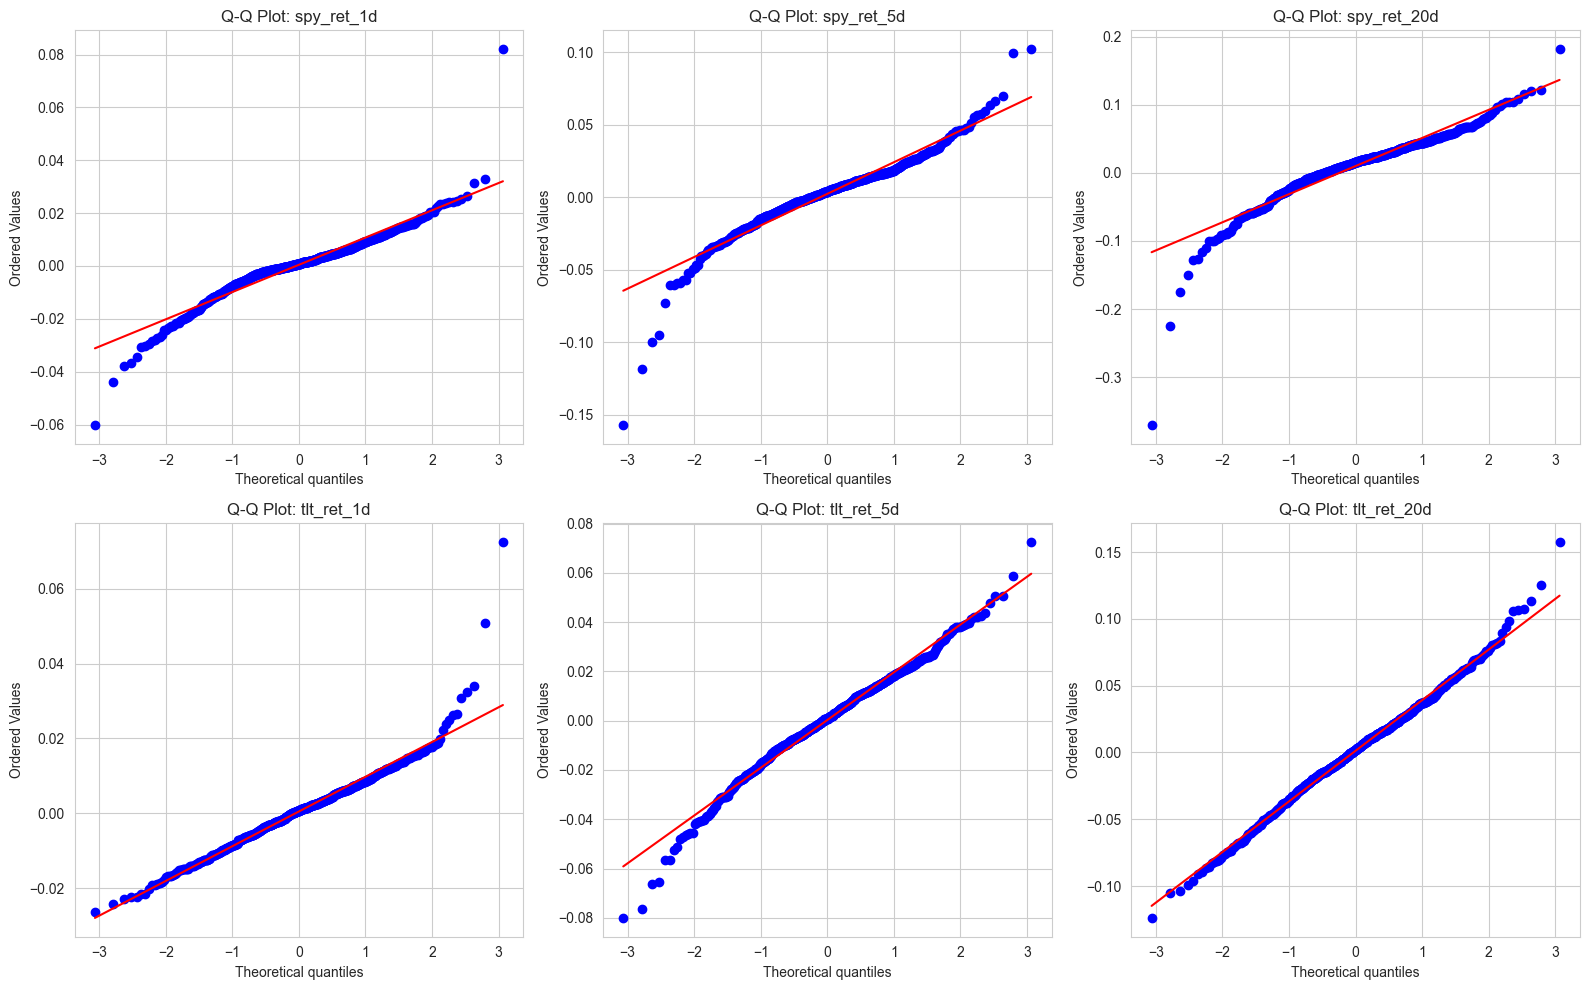

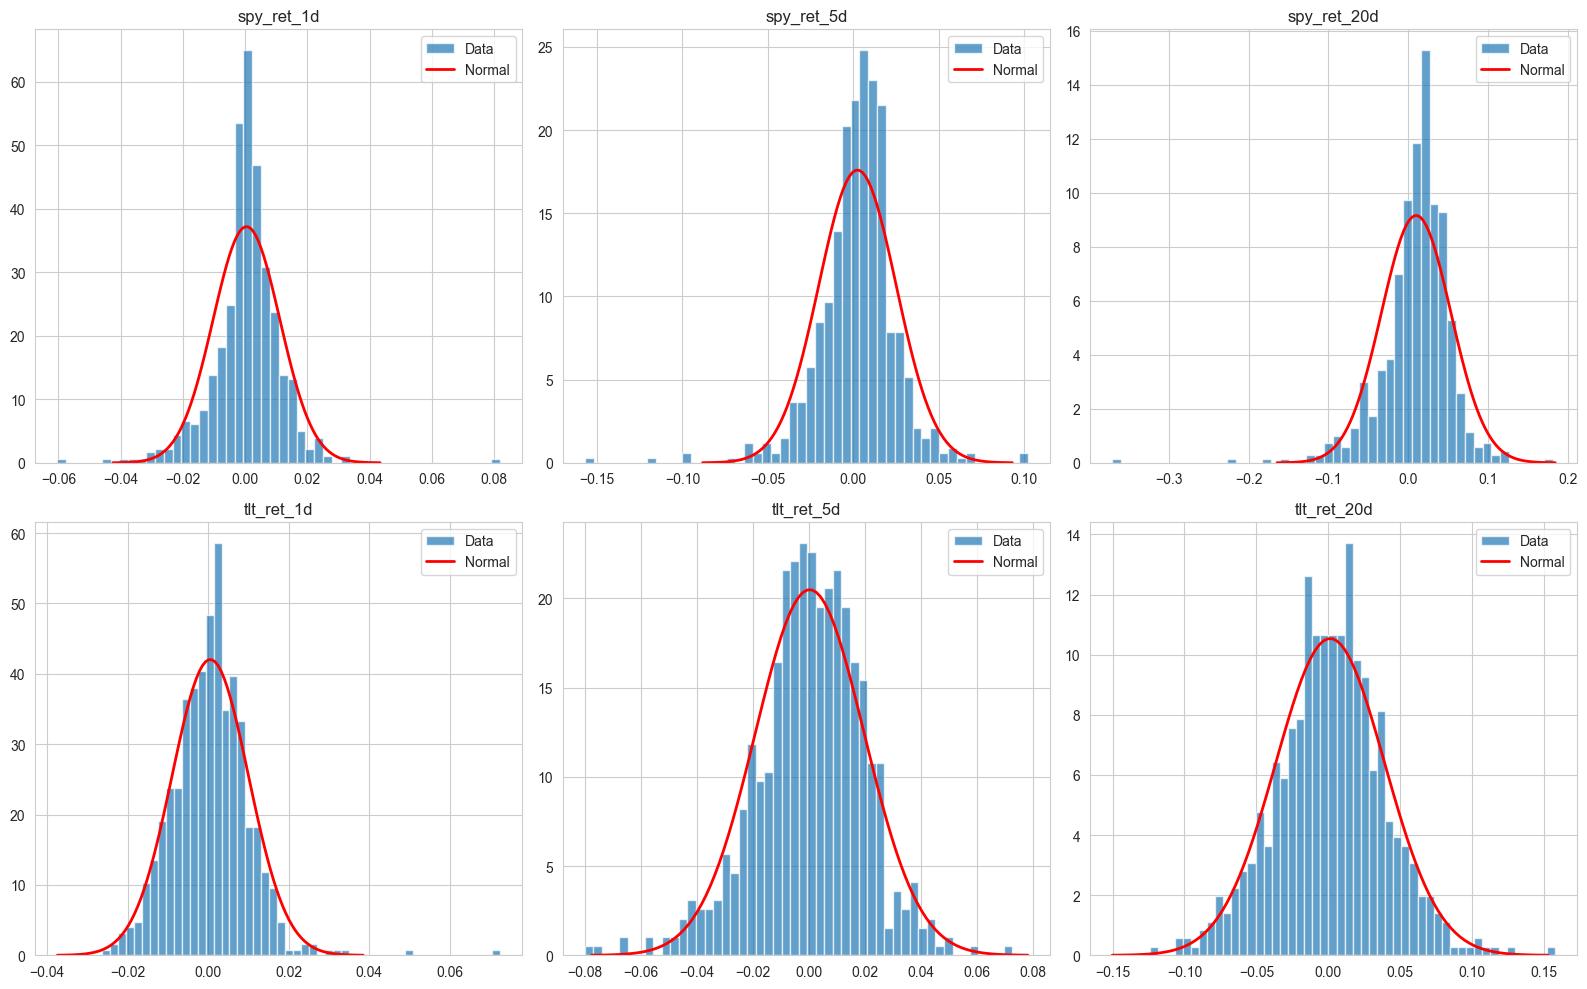

In [14]:
# Q-Q plots to check for normality
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(key_returns[:6]):
    data_clean = df_market[col].dropna()
    stats.probplot(data_clean, dist="norm", plot=axes[idx])
    axes[idx].set_title(f'Q-Q Plot: {col}')

plt.tight_layout()
plt.show()

# Distribution comparison: Histogram vs Normal
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(key_returns[:6]):
    data_clean = df_market[col].dropna()
    axes[idx].hist(data_clean, bins=50, density=True, alpha=0.7, label='Data')
    
    # Overlay normal distribution
    mu, sigma = data_clean.mean(), data_clean.std()
    x = np.linspace(mu - 4*sigma, mu + 4*sigma, 100)
    axes[idx].plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Normal')
    axes[idx].set_title(f'{col}')
    axes[idx].legend()

plt.tight_layout()
plt.show()

## Summary and Insights

### Data Overview
- **Dataset Size**: Market features with weekly frequency covering multiple years
- **Time Range**: From 2014 to 2015 (and potentially beyond)
- **Features**: 36+ features tracking returns, volatility, and cross-asset correlations for SPY, TLT, GLD, and QQQ

### Key Findings

#### 1. Missing Data
The dataset has missing values, particularly in early periods (2014 early weeks). This likely reflects data collection ramp-up.

#### 2. Distribution Characteristics
- Returns are generally **not normally distributed** (non-zero skewness, excess kurtosis)
- Volatility features show right skew with occasional spikes
- VIX shows significant clustering behavior during market stress periods

#### 3. Correlation Insights  
- Strong positive correlations between returns at different time horizons (1d, 5d, 20d)
- Asset returns (SPY, TLT, GLD) show varying correlation dynamics
- Volatility metrics are highly correlated across assets

#### 4. Outliers
- Significant outliers identified in both returns and volatility
- Outlier clusters correspond to known market stress events (2015 August market correction visible)

#### 5. Time Series Patterns
- Clear trends in market regimes (volatility regimes visible in VIX/volatility series)
- Asset returns show regime-switching behavior
- Potential for regime detection models given observed patterns

### Recommendations for Modeling
1. **Handle Missing Data**: Use forward fill or interpolation for early periods
2. **Feature Scaling**: Normalize features before feeding to ML models
3. **Outlier Treatment**: Consider robust scaling or outlier winsorization
4. **Regime Definition**: Use volatility/VIX spikes to identify regimes for RL agent training
5. **Correlation Monitoring**: Watch for correlation breakdown during stress periods